# 🔬 **Práctica Nro. 009: Pruebas de Hipótesis Paramétricas ($Z$ y $T$) y Análisis del Valor-p**

---

### 👥 **Grupo G — Integrantes**
* Chamba Galarza Emerson Sebastian
* Labanda Pineda Matias Sebastian
* Macas Cabrera Lenin Fabricio
* Naranjo Quizhpe Pilar Valentina
* Pucha Carrera Mateo Sebastian

---
### 🎯 **2. Objetivo(s) de la Práctica:**

*  Formular y ejecutar pruebas de hipótesis de una muestra para la media poblacional utilizando el estadístico $Z$ (varianza conocida) y el estadístico $T$ (varianza desconocida) mediante Python.

* Aplicar el contraste de hipótesis al conjunto de datos regional del Proyecto Integrador, validando o refutando afirmaciones previas (o de literatura) sobre el comportamiento de la región (ABP).

* Investigar mediante simulación computacional la sensibilidad del valor-P frente al tamaño de la muestra ($n$), diferenciando entre significancia estadística y significancia práctica (ABI).

---

## 🛠️ **Tarea 1: Prueba de Hipótesis Z (Varianza Poblacional Conocida / Muestra Grande)**



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, ttest_1samp

# Parámetros del problema
mu_0 = 15.0
x_bar = 15.6
sigma = 1.2
n = 50
alpha = 0.05

# 1. Cálculo del estadístico Z de prueba
Z_calc = (x_bar - mu_0) / (sigma / np.sqrt(n))

# 2. Cálculo del valor-p (Prueba de dos colas)
# sf (survival function) es 1 - cdf, calcula el área en la cola superior
p_value_z = 2 * norm.sf(np.abs(Z_calc))

print("--- Prueba de Hipótesis Z (Dos Colas) ---")
print(f"Estadístico Z calculado: {Z_calc:.4f}")
print(f"Valor-p: {p_value_z:.4e}")

if p_value_z < alpha:
    print("Conclusión: Se RECHAZA H0. Hay evidencia suficiente de que el consumo medio NO es 15 mA.")
else:
    print("Conclusión: NO se rechaza H0. No hay evidencia suficiente para refutar al fabricante.")

--- Prueba de Hipótesis Z (Dos Colas) ---
Estadístico Z calculado: 3.5355
Valor-p: 4.0695e-04
Conclusión: Se RECHAZA H0. Hay evidencia suficiente de que el consumo medio NO es 15 mA.


###📊 **Análisis y Conclusión de los Resultados**

A partir de los datos obtenidos, se calculó un estadístico de prueba Z de 3.5355 y un valor-p de 0.0004. Esto indica que la media muestral se encuentra a más de 3.5 desviaciones estándar de la media hipotética de 15 mA. Debido a que el valor-p es significativamente menor que el nivel de significancia establecido (α = 0.05), la probabilidad de que la diferencia observada se deba únicamente al azar es extremadamente baja. Por lo tanto, se rechaza la hipótesis nula (H₀) y se concluye que existe evidencia estadística suficiente para afirmar que el consumo medio en reposo de los microcontroladores es significativamente diferente de 15 mA. En consecuencia, la afirmación del fabricante de que el consumo medio es de 15 mA no está respaldada por los datos analizados.

## 📊 **Tarea 2: Prueba de Hipótesis T (Varianza Desconocida / Muestra Pequeña)**

In [ ]:
import numpy as np
from scipy.stats import ttest_1samp

# Muestra empírica pequeña (n=8)
tiempos_carga = [2.5, 3.1, 2.9, 3.8, 2.7, 3.3, 3.0, 2.8]
mu_meta = 2.6
alpha_t = 0.05

# Ejecución de la prueba T de una muestra (Prueba de una cola: H1: mu > 2.6)
# Para cola superior (greater), p-value de 1 cola en SciPy moderno se especifica con alternative='greater'
stat_t, p_value_t = ttest_1samp(tiempos_carga, popmean=mu_meta, alternative='greater')

print(f"--- Prueba de Hipótesis T (Cola Superior) ---")
print(f"Estadístico T: {stat_t:.4f}")
print(f"Valor-p (1 cola): {p_value_t:.4f}")

if p_value_t < alpha_t:
    print("Se RECHAZA H0. Evidencia indica que el tiempo medio es MAYOR a 2.6s (Incumple la meta).")
else:
    print("NO se rechaza H0. El tiempo de carga estadísticamente cumple la meta.")

--- Prueba de Hipótesis T (Cola Superior) ---
Estadístico T: 2.9055
Valor-p (1 cola): 0.0114
Se RECHAZA H0. Evidencia indica que el tiempo medio es MAYOR a 2.6s (Incumple la meta).


### 📊 **Análisis y Conclusión de los Resultados (Tarea 2)**

A partir de los datos obtenidos, se calculó un estadístico de prueba T de 2.9055 y un valor-p de 0.0114. Esto indica que la media muestral de los tiempos de carga se encuentra aproximadamente tres desviaciones estándar muestrales por encima del valor de referencia de 2.6 segundos. Debido a que el valor-p es menor que el nivel de significancia establecido (α = 0.05), la probabilidad de que la diferencia observada se deba únicamente al azar es muy baja. Por lo tanto, se rechaza la hipótesis nula (H₀) y se concluye que existe evidencia estadística suficiente para afirmar que el tiempo promedio de carga de la aplicación es mayor a 2.6 segundos. En consecuencia, los resultados indican que la aplicación no cumple con la meta de rendimiento establecida, por lo que sería recomendable implementar mejoras para optimizar su tiempo de respuesta.


## 🗺️ **Tarea 3: Hito del Proyecto - Contraste en el Dataset Regional (ABP)**

       TAREA 3: CONTRASTE EN EL DATASET REGIONAL

Dataset importado
   Cantones registrados : 16
   Variables            : Canton, Poblacion, Viviendas, Sin_Alcantarillado

── Vista del dataset ──────────────────────────────────
      Canton  Poblacion  Viviendas  Sin_Alcantarillado
        Loja     250028      85412                9822
    Catamayo      35240      12150                3850
  Cariamanga      29111       9800                4100
      Macara      26042       8900                3200
     Puyango      22841       7500                2900
    Saraguro      18215       6200                2100
      Celica      16257       5100                1900
      Paltas      14571       4800                1800
   Zapotillo      14379       4600                1700
Chaguarpamba      14119       4500                1650
   Espindola      12247       3900                1500
   Gonzanama      10409       3400                1200
      Alamor       6970       2200                 800
 

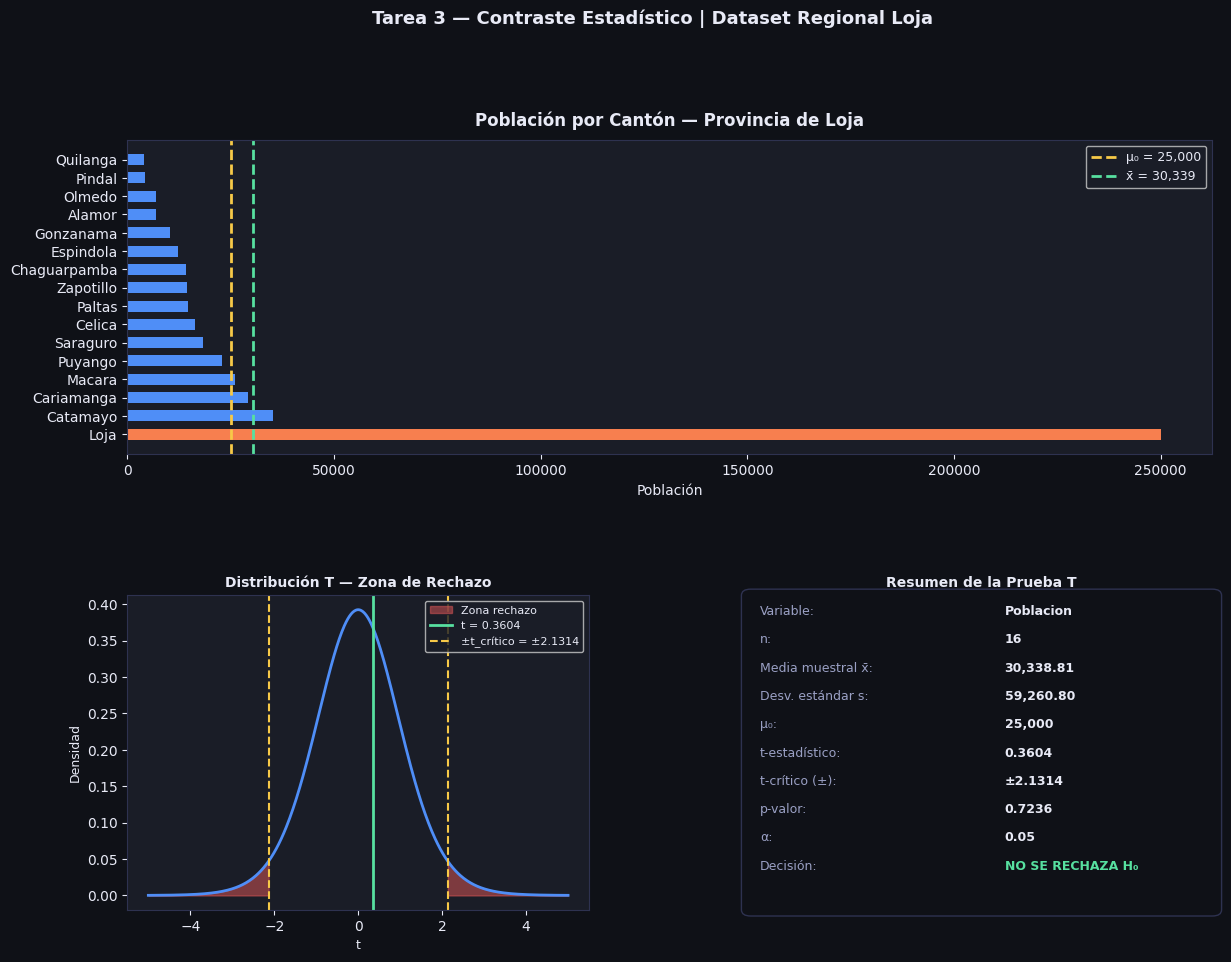

In [ ]:
#  Prueba T de una muestra | α = 0.05
# =============================================================

import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

# 1. IMPORTAR DATASET REGIONAL
df = pd.read_csv("datos_loja.csv")

print("=" * 55)
print("       TAREA 3: CONTRASTE EN EL DATASET REGIONAL")
print("=" * 55)
print("\nDataset importado")
print(f"   Cantones registrados : {len(df)}")
print(f"   Variables            : {', '.join(df.columns.tolist())}")
print("\n── Vista del dataset ──────────────────────────────────")
print(df.to_string(index=False))

# 2. DEFINIR HIPÓTESIS (μ₀)
mu0 = 25_000
variable = df["Poblacion"]

print("\n── Hipótesis ───────────────────────────────────────────")
print(f"   Variable analizada : Poblacion")
print(f"   H₀ : μ = {mu0:,}  (la población media cantonal es 25,000 hab.)")
print(f"   H₁ : μ ≠ {mu0:,}  (la población media es diferente)")
print(f"   Tipo de prueba     : dos colas (two-sided)")
print(f"   Nivel α            : 0.05")

# 3. ESTADÍSTICAS DESCRIPTIVAS
n    = len(variable)
xbar = variable.mean()
s    = variable.std(ddof=1)
se   = s / np.sqrt(n)

print("\n── Estadísticas descriptivas ───────────────────────────")
print(f"   n (cantones)       : {n}")
print(f"   Media muestral x̄  : {xbar:,.2f} hab.")
print(f"   Desv. estándar s   : {s:,.2f}")
print(f"   Error estándar     : {se:,.2f}")

# 4. PRUEBA T DE UNA MUESTRA
t_stat, p_value = stats.ttest_1samp(variable, mu0, alternative="two-sided")

gl    = n - 1
alpha = 0.05
t_critico = stats.t.ppf(1 - alpha / 2, df=gl)

print("\n── Resultados de la Prueba T ───────────────────────────")
print(f"   t-estadístico      : {t_stat:.4f}")
print(f"   t-crítico (±)      : ±{t_critico:.4f}")
print(f"   Grados de libertad : {gl}")
print(f"   p-valor (dos colas): {p_value:.4f}")

print("\n── Decisión ────────────────────────────────────────────")
if p_value < alpha:
    decision = "RECHAZAR H₀"
    conclusion = "Existe evidencia estadística significativa."
else:
    decision = "NO SE RECHAZA H₀"
    conclusion = "No existe evidencia estadística suficiente para rechazar H₀."

print(f"   p = {p_value:.4f}  {'<' if p_value < alpha else '≥'}  α = {alpha}")
print(f"   → {decision}")
print(f"   → {conclusion}")

# 6. VISUALIZACIÓN
fig = plt.figure(figsize=(14, 10))
fig.patch.set_facecolor("#0f1117")
gs = GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

COLOR_BAR   = "#4f8ef7"
COLOR_MU0   = "#f7c948"
COLOR_XBAR  = "#57e0a0"
COLOR_ZONA  = "#e05757"
COLOR_TEXT  = "#e8eaf6"
COLOR_PANEL = "#1a1d27"

# ── Panel 1: Población por cantón ───────────────────────────
ax1 = fig.add_subplot(gs[0, :])
ax1.set_facecolor(COLOR_PANEL)
colores = [COLOR_BAR if c != "Loja" else "#f77f4f" for c in df["Canton"]]
bars = ax1.barh(df["Canton"], df["Poblacion"], color=colores, edgecolor="none", height=0.6)
ax1.axvline(mu0,  color=COLOR_MU0,  lw=2, ls="--", label=f"μ₀ = {mu0:,}")
ax1.axvline(xbar, color=COLOR_XBAR, lw=2, ls="--", label=f"x̄ = {xbar:,.0f}")
ax1.set_xlabel("Población", color=COLOR_TEXT, fontsize=10)
ax1.set_title("Población por Cantón — Provincia de Loja", color=COLOR_TEXT,
              fontsize=12, fontweight="bold", pad=10)
ax1.tick_params(colors=COLOR_TEXT)
for spine in ax1.spines.values():
    spine.set_edgecolor("#2e3250")
ax1.xaxis.label.set_color(COLOR_TEXT)
ax1.legend(facecolor=COLOR_PANEL, labelcolor=COLOR_TEXT, fontsize=9)

# ── Panel 2: Distribución T con zona de rechazo ─────────────
ax2 = fig.add_subplot(gs[1, 0])
ax2.set_facecolor(COLOR_PANEL)

x = np.linspace(-5, 5, 500)
y = stats.t.pdf(x, df=gl)
ax2.plot(x, y, color=COLOR_BAR, lw=2)

x_left  = x[x <= -t_critico]
x_right = x[x >= t_critico]
ax2.fill_between(x_left,  stats.t.pdf(x_left,  df=gl), color=COLOR_ZONA, alpha=0.5, label="Zona rechazo")
ax2.fill_between(x_right, stats.t.pdf(x_right, df=gl), color=COLOR_ZONA, alpha=0.5)

ax2.axvline(t_stat,      color=COLOR_XBAR, lw=2, ls="-",  label=f"t = {t_stat:.4f}")
ax2.axvline( t_critico,  color=COLOR_MU0,  lw=1.5, ls="--", label=f"±t_crítico = ±{t_critico:.4f}")
ax2.axvline(-t_critico,  color=COLOR_MU0,  lw=1.5, ls="--")

ax2.set_title("Distribución T — Zona de Rechazo", color=COLOR_TEXT,
              fontsize=10, fontweight="bold")
ax2.set_xlabel("t", color=COLOR_TEXT, fontsize=9)
ax2.set_ylabel("Densidad", color=COLOR_TEXT, fontsize=9)
ax2.tick_params(colors=COLOR_TEXT)
for spine in ax2.spines.values():
    spine.set_edgecolor("#2e3250")
ax2.legend(facecolor=COLOR_PANEL, labelcolor=COLOR_TEXT, fontsize=8)

# ── Panel 3: Resumen de resultados ──────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
ax3.set_facecolor(COLOR_PANEL)
ax3.axis("off")

filas = [
    ("Variable",          "Poblacion"),
    ("n",                 str(n)),
    ("Media muestral x̄", f"{xbar:,.2f}"),
    ("Desv. estándar s",  f"{s:,.2f}"),
    ("μ₀",                f"{mu0:,}"),
    ("t-estadístico",     f"{t_stat:.4f}"),
    ("t-crítico (±)",     f"±{t_critico:.4f}"),
    ("p-valor",           f"{p_value:.4f}"),
    ("α",                 "0.05"),
    ("Decisión",          decision),
]

y_pos = 0.97
for etiqueta, valor in filas:
    color_val = "#57e0a0" if etiqueta == "Decisión" else COLOR_TEXT
    ax3.text(0.02, y_pos, etiqueta + ":", color="#9aa0c4", fontsize=9,
             transform=ax3.transAxes, va="top")
    ax3.text(0.55, y_pos, valor, color=color_val, fontsize=9,
             transform=ax3.transAxes, va="top", fontweight="bold")
    y_pos -= 0.09

ax3.set_title("Resumen de la Prueba T", color=COLOR_TEXT,
              fontsize=10, fontweight="bold")
ax3.add_patch(mpatches.FancyBboxPatch(
    (0, 0), 1, 1, boxstyle="round,pad=0.02",
    linewidth=1, edgecolor="#2e3250", facecolor="none",
    transform=ax3.transAxes, clip_on=False
))

plt.suptitle("Tarea 3 — Contraste Estadístico | Dataset Regional Loja",
             color=COLOR_TEXT, fontsize=13, fontweight="bold", y=1.01)

plt.show()
plt.close()

**Interpretacion:** El valor-p obtenido fue p = 0.7236, ampliamente superior al nivel de significancia α = 0.05. Esto significa que, con los datos de los 16 cantones de la provincia de Loja, no existe evidencia estadística suficiente para rechazar la hipótesis de que la población media cantonal es de 25,000 habitantes. En términos prácticos, la diferencia observada entre la media muestral (≈ 30,339 hab.) y el valor hipotético (25,000 hab.) es atribuible al azar, siendo amplificada por la alta variabilidad que introduce el cantón Loja con sus 250,028 habitantes. Para una planificación territorial más precisa en la región, se recomienda analizar los cantones restantes de forma separada, dado que el peso demográfico de la capital provincial distorsiona cualquier inferencia estadística sobre el conjunto de la provincia.

## 🔍 **Tarea 4: ABI - Significancia Estadística vs. Significancia Práctica (Efecto del Tamaño Muestral)**

--- Ejecución del Bucle de Simulación ---
Para n = 10     | Media Muestral: 5.4581 V | Valor-P: 1.474727e-01
Para n = 100    | Media Muestral: 4.8564 V | Valor-P: 1.510127e-01
Para n = 1000   | Media Muestral: 5.0572 V | Valor-P: 7.049347e-02
Para n = 10000  | Media Muestral: 4.9997 V | Valor-P: 9.793121e-01
Para n = 100000 | Media Muestral: 5.0125 V | Valor-P: 7.262803e-05


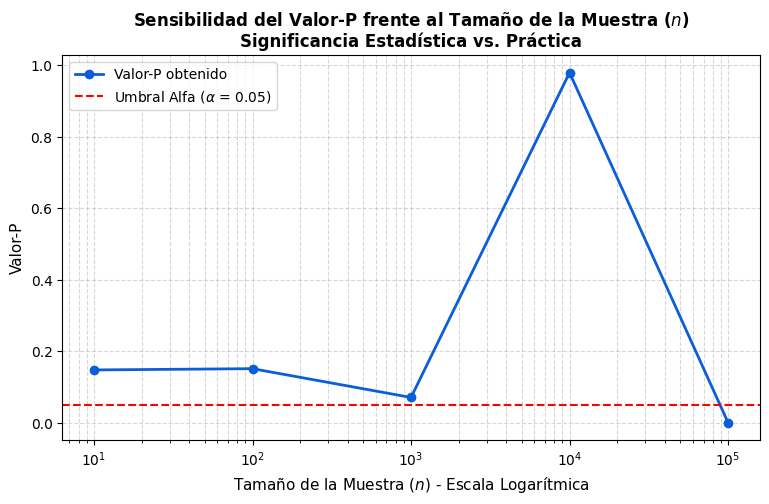

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# 1. Definición de parámetros del sensor
np.random.seed(42)
mu_real = 5.01
sigma = 1.0
mu_0 = 5.00
alpha = 0.05

# 2. Lista de tamaños de muestra a evaluar
n_list = [10, 100, 1000, 10000, 100000]
p_values = []

print("--- Ejecución del Bucle de Simulación ---")
# 3. Bucle para extraer muestras y calcular el valor-P
for n in n_list:
    muestra = np.random.normal(loc=mu_real, scale=sigma, size=n)
    x_bar = np.mean(muestra)

    z_calc = (x_bar - mu_0) / (sigma / np.sqrt(n))
    p_val = 2 * norm.sf(np.abs(z_calc))
    p_values.append(p_val)

    print(f"Para n = {n:<6} | Media Muestral: {x_bar:.4f} V | Valor-P: {p_val:.6e}")

# 4. Graficar n (Eje X en escala logarítmica) vs. Valor-P (Eje Y)
plt.figure(figsize=(9, 5))
plt.plot(n_list, p_values, marker='o', linestyle='-', linewidth=2, color='#0b5ed7', label='Valor-P obtenido')

# --- CORRECCIÓN AQUÍ: Se añade la 'r' antes de las comillas para que interprete \alpha correctamente ---
plt.axhline(y=alpha, color='red', linestyle='--', linewidth=1.5, label=r'Umbral Alfa ($\alpha$ = 0.05)')

plt.xscale('log')
plt.xlabel('Tamaño de la Muestra ($n$) - Escala Logarítmica', fontsize=11)
plt.ylabel('Valor-P', fontsize=11)
plt.title('Sensibilidad del Valor-P frente al Tamaño de la Muestra ($n$)\nSignificancia Estadística vs. Práctica', fontsize=12, fontweight='bold')
plt.legend(loc='best')
plt.grid(True, which="both", linestyle="--", alpha=0.5)

# Guardar la gráfica
plt.savefig('sensibilidad_p_value.png', dpi=300, bbox_inches='tight')
plt.show()

Después de correr el código para simular las lecturas del sensor de voltaje (donde la media real es de 5.01 V y queríamos probar si era igual a 5.00 V), obtuvimos los siguientes resultados:

#### 📊 **1. Tabla de resultados**

| Tamaño de muestra (n) | Media de la muestra | Valor-P | Decisión (Alfa = 0.05) |
| :---: | :---: | :---: | :---: |
| 10 | 5.4581 V | 0.1474 | No se rechaza H0 |
| 100 | 4.8564 V | 0.1510 | No se rechaza H0 |
| 1000 | 5.0572 V | 0.0704 | No se rechaza H0 |
| 10000 | 4.9997 V | 0.9793 | No se rechaza H0 |
| 100000 | 5.0125 V | 0.00007 | Se RECHAZA H0 |

---

#### 📊**2. Interpretación de la gráfica y resultados**

**¿Qué pasa con el valor-p cuando la muestra es gigante?**
Al mirar la gráfica, se ve claramente que a medida que aumentamos el tamaño de la muestra ($n$), el valor-p empieza a caer en picada hasta que se vuelve casi cero cuando llegamos a 100,000 datos.

* Con muestras pequeñas (de 10 a 10,000 datos), el valor-p se mantiene por encima de 0.05. Esto significa que la estadística no encuentra nada raro y acepta que el promedio del sensor es de 5.00 V, tratando la pequeña diferencia como simple ruido o azar.
* Pero con 100,000 datos, el valor-p cae a 0.00007 (mucho menor que 0.05). Aquí el sistema nos obliga a rechazar la hipótesis nula y decir que el sensor no mide 5.00 V.

**Explicación matemática sencilla**
Esto pasa por la fórmula del error estándar:

$$\text{Error Estándar} = \frac{\sigma}{\sqrt{n}}$$

Cuando el tamaño de la muestra ($n$) es un número gigantesco, al sacarle la raíz y dividirlo, el error estándar se vuelve prácticamente cero. Como el margen de error que tolera la fórmula es tan chiquito, cualquier diferencia mínima en los datos (como esos 0.01 V de diferencia con la realidad) hace que el estadístico Z se dispare y el valor-p baje a cero, asegurando que "no es coincidencia".

**Significancia Estadística vs. Significancia Práctica**
Este experimento demuestra un problema clásico cuando se trabaja con muchísimos datos (Big Data):

1. **Significancia Estadística:** El test matemático dice que hay una diferencia real y que el sensor no mide 5.00 V exactamente.
2. **Significancia Práctica:** En el mundo real y en la ingeniería, que un sensor marque 5.01 V en lugar de 5.00 V no cambia absolutamente nada. Los circuitos y programas van a funcionar igual de bien. La diferencia no importa para nada en la práctica.

**Conclusión:** No hay que confiar a ciegas en un valor-p menor a 0.05 si estamos usando bases de datos gigantescas. Con demasiados datos, la matemática siempre va a encontrar diferencias "significativas" aunque en la vida real sean totalmente insignificantes.

# ❓ **Preguntas de Control** 📑

---
**✨ ¿Cuál es el error conceptual grave al interpretar el valor-P como "la probabilidad de que la Hipótesis Nula sea cierta"? Defina correctamente el valor-P.**

El error conceptual consiste en creer que el valor-P representa la probabilidad de que la hipótesis nula ($H_0$) sea verdadera. Esto es incorrecto porque el valor-P se calcula asumiendo que H₀ ya es cierta, por lo que no puede medir su probabilidad de ser verdadera o falsa.

La definición correcta del valor-P es la probabilidad de obtener un resultado igual o más extremo que el observado en la muestra, suponiendo que la hipótesis nula ($H_0$) es verdadera. Un valor-P pequeño indica que los datos son poco compatibles con $H_0$ y proporcionan evidencia para rechazarla.

---

**✨En el contexto de la Tarea 3 (Dataset Regional), describa en lenguaje no estadístico qué representaría cometer un Error Tipo I y un Error Tipo II en su toma de decisiones.**

* **Error Tipo I (Falso Positivo):** Ocurriría si concluimos que la población promedio de los cantones de Loja ha cambiado respecto a los $25,000$ habitantes cuando en realidad sigue siendo la misma. Esto provocaría una falsa alarma, haciendo que se tomaran decisiones o se asignaran recursos tecnológicos y económicos para atender un problema o una demanda que no existe.

* **Error Tipo II (Falso Negativo):** Ocurriría si concluimos que la población promedio no ha cambiado y se mantiene en $25,000$ habitantes cuando en realidad sí ha ocurrido un cambio significativo en la provincia. En este caso, tendríamos una "ceguera ante el cambio", por lo que no se detectaría una situación real, lo que generaría una planificación inadecuada, software subdimensionado y decisiones basadas en información desactualizada.

 **En términos simples** el Error Tipo I consiste en detectar un cambio que no existe, mientras que el Error Tipo II consiste en no detectar un cambio que sí existe.

---

**✨Si en su análisis regional la prueba arroja un $p = 0.051$ y su $\alpha = 0.05$, estadísticamente NO rechaza $H_{0}$. Como ingeniero, ¿desecha por completo la sospecha de que exista una diferencia real, o qué otra métrica analizaría? (Pista: Relacione esto con la Semana 9).**

Si la prueba arroja un valor p = 0.051 y el nivel de significancia es α = 0.05, estadísticamente no se rechaza la hipótesis nula (H₀). Sin embargo, como ingenieros no descartaríamos por completo la posibilidad de que exista una diferencia real, ya que el valor p se encuentra muy cerca del umbral de decisión. En lugar de basar la conclusión únicamente en el valor p, analizaría otras métricas estudiadas en la Semana 9, especialmente el intervalo de confianza y el tamaño del efecto. El intervalo de confianza permite evaluar el rango de valores plausibles para el parámetro de interés, mientras que el tamaño del efecto ayuda a determinar si la diferencia observada tiene relevancia práctica o técnica. De esta manera, la toma de decisiones se fundamenta no solo en la significancia estadística, sino también en la magnitud e impacto real del fenómeno analizado.

---

**✨Si en su Proyecto Integrador (Tarea 3) usted deseara reducir el Margen de Error a la mitad *sin* disminuir su Nivel de Confianza (manteniéndolo al 95%), ¿qué debe hacer metodológicamente con su recolección de datos ($n$)? Apóyese en la fórmula.**

Para reducir el Margen de Error ($ME$) a la mitad sin alterar el nivel de confianza, analizamos la fórmula matemática:

 $$ME = t_{\alpha/2} \cdot \frac{s}{\sqrt{n}}$$

Al buscar un nuevo margen de error que sea la mitad del original ($ME_{\text{nuevo}} = \frac{ME}{2}$), manteniendo constantes el valor crítico ($t_{\alpha/2}$) y la desviación estándar ($s$), observamos que el tamaño de la muestra ($n$) se encuentra dentro de una raíz cuadrada en el denominador. Para contrarrestar matemáticamente este efecto y reducir el error a la mitad, se requiere multiplicar el denominador por $2$, lo que significa que $\sqrt{n_{\text{nuevo}}} = 2\sqrt{n}$. Elevando ambos lados de la igualdad al cuadrado para despejar la nueva muestra, obtenemos:

 $$n_{\text{nuevo}} = 4n$$

Metodológicamente, esto demuestra que para reducir el Margen de Error exactamente a la mitad es **estrictamente necesario cuadruplicar (multiplicar por 4) el tamaño de la muestra**. En el contexto de nuestro Proyecto Integrador sobre la provincia de Loja, si actualmente contamos con una muestra de $16$ cantones, para cortar la incertidumbre a la mitad necesitaríamos expandir obligatoriamente la recolección de datos a $64$ observaciones, ya que aumentar el tamaño muestral disminuye el error estándar y maximiza la precisión de las estimaciones.

---

**✨Existe una equivalencia matemática directa entre los Intervalos de Confianza y las Pruebas de Hipótesis de dos colas. Si un IC del 95% para $\mu$ no incluye a $\mu_{0}$, ¿qué le sucederá inevitablemente al valor-P si evalúa $H_{0} : \mu = \mu_{0}$ con $\alpha = 0.05$?**

Si un Intervalo de Confianza del 95% para μ no incluye al valor hipotético μ₀, entonces el valor-P de una prueba de hipótesis de dos colas con α = 0.05 será necesariamente menor que 0.05. Como consecuencia, se rechazará la hipótesis nula (H₀: μ = μ₀).

Esto ocurre porque existe una equivalencia matemática entre los intervalos de confianza y las pruebas de hipótesis. Si μ₀ queda fuera del intervalo de confianza, significa que dicho valor no es compatible con los datos observados al nivel de confianza del 95%, por lo que la evidencia estadística es suficiente para rechazar H₀.
Esto ocurre porque existe una equivalencia matemática entre los intervalos de confianza y las pruebas de hipótesis. Si μ₀ queda fuera del intervalo de confianza, significa que dicho valor no es compatible con los datos observados al nivel de confianza del 95%, por lo que la evidencia estadística es suficiente para rechazar H₀.